# 1. Import Libraries and CSV

Following our ARIMA models and autoarima EDA, we're going to want to confirm many of autoarima's findings for academic rigor and validity manually.

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import statsmodels.tsa.vector_ar.vecm as vecm

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("DC_Master_Missing.csv", parse_dates=['Date'], index_col='Date')

print(df.tail())

# 2. Sort Columns Again

In [ ]:
df = pd.read_csv('DC_Master_Missing.csv', index_col=0, parse_dates=True) 

# Calculate missing values per column
missing_counts = df.isnull().sum()

# Sort columns by missing count (least to most)
print("\nSorting columns")
sorted_columns = missing_counts.sort_values().index.tolist()
print("Pandas Sort Order:", sorted_columns)

# 3. Run KPSS and Stationarity Tests

Let's recall our previous results from autoarima, and let's see if the results are the same for KPSS and ADF.

* **Unemployment_Rate**: `ARIMA(2,0,1)(1,0,0)[4]` -> `d=0`, `D=0` (Suggests original series is stationary)
* **Interest_Rate**: `ARIMA(2,1,2)(0,0,0)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **Mortgage_Rate**: `ARIMA(0,1,0)(0,0,0)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **CPI**: `ARIMA(1,1,0)(1,0,1)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **House_Index**: `ARIMA(0,1,3)(1,0,0)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **GDP**: `ARIMA(0,2,1)(0,0,0)[4]` -> `d=2`, `D=0` (Suggests 2nd order differencing needed)
* **Population**: `ARIMA(1,1,0)(0,0,1)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **Poverty_Rate**: `ARIMA(2,1,0)(1,0,2)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)
* **Median_Household_Income**: `ARIMA(1,1,3)(0,0,0)[4]` -> `d=1`, `D=0` (Suggests 1st order differencing needed)

In [ ]:
def test_stationarity(timeseries):
    series = df[col_name]
    
    # Check if the column has any missing values
    train_data = series.dropna()

    ADF_Stationary = False
    KPSS_Stationary = False

    Stationary = False

    # Run ADFuller test
    adf_result = adfuller(train_data)
    adf_p_value = adf_result[1]

    if adf_p_value <= 0.05:
        ADF_Stationary = True
        print(f"ADF Test: Stationary (p-value: {adf_p_value:.4f})")
    else:
        print(f"ADF Test: Non-stationary (p-value: {adf_p_value:.4f})")

    # Run KPSS test
    kpss_result = kpss(train_data, regression='c')
    kpss_p_value = kpss_result[1]

    if kpss_p_value >= 0.05:
        KPSS_Stationary = True
        print(f"KPSS Test: Stationary (p-value: {kpss_p_value:.4f})")
    else:
        print(f"KPSS Test: Non-stationary on c (p-value: {kpss_p_value:.4f})\ntrying with trend regression")
        # Run KPSS test with trend regression
        kpss_result = kpss(train_data, regression='ct')
        kpss_p_value = kpss_result[1]
        if kpss_p_value >= 0.05:
            KPSS_Stationary = True
            print(f"KPSS Test: Stationary on ct(p-value: {kpss_p_value:.4f})")
        else:
            print(f"KPSS Test: Non-stationary on ct (p-value: {kpss_p_value:.4f})")
    
    # Combined interpretation of ADF and KPSS results
    if ADF_Stationary and KPSS_Stationary:
        Stationary = True
        print(f"Final Decision: Stationary")
    elif not ADF_Stationary and KPSS_Stationary:
        print(f"Final Decision: Non-stationary")
    else:
        print(f"Final Decision: Mixed results, further analysis needed")

In [ ]:
# For loop to run kpss and stationarity tests on each column
for col_name in sorted_columns:
    print(f"\nProcessing column: {col_name}")
    
    col_name = test_stationarity(df[col_name])

Unemployment rate is already stationary! No differencing required there.

In [ ]:
# First, create differenced columns
for col_name in ['Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index', 'GDP', 'Population', 'Poverty_Rate', 'Median_Household_Income']:
    diff_col = f'{col_name}_diff1'
    df[diff_col] = df[col_name].diff()

In [ ]:
# Run differenced columns through the stationarity tests
for col_name in ['Interest_Rate_diff1', 'Mortgage_Rate_diff1', 'CPI_diff1', 'House_Index_diff1', 'GDP_diff1', 'Population_diff1', 'Poverty_Rate_diff1', 'Median_Household_Income_diff1']:
    print(f"\nProcessing column: {col_name}")
    
    col_name = test_stationarity(df[col_name])

Interest Rate, Mortgage Rate, CPI, House Index, Poverty Rate, and Median Household income are stationary at integrated of order 1, let's see what we find with another difference on GDP and population.

In [ ]:
# Create 2nd differenced columns for GDP and Population
for col_name in ['GDP_diff1', 'Population_diff1']:
    diff_col2 = f'{col_name}_diff2'
    df[diff_col2] = df[col_name].diff()

In [ ]:
# Ensure 2nd differenced columns are created
for col_name in ['GDP_diff1', 'Population_diff1']:
    diff_col2 = col_name.replace('diff1', 'diff2')  # Replace 'diff1' with 'diff2'
    df[diff_col2] = df[col_name].diff()

# Run 2nd differenced columns through the stationarity tests
for col_name in ['GDP_diff2', 'Population_diff2']:
    print(f"\nProcessing column: {col_name}")
    
    test_stationarity(df[col_name])

Stationarity was confirmed using the ADF test on the second-differenced series (p < 0.05). Although the KPSS test marginally rejected the null of stationarity (p ≈ 0.0417), the evidence was not strong, and AutoARIMA modeling supported second differencing (d = 2). We'll just go with l2. We also want to note that autoarima chose l1 for population, which makes sense considering that it marginally fails the ADF fuller test at 0.812 at the first difference.

# 4. Seasonal Decomposition Visualization

Since D = 0 from autoarima, it did not need to do differencing for seasonal components, but it was P = 1 for 3, meaning there's a seasonal component it adjusted for based on the previous year's season, but not between seasons. Let's visualize it.

In [ ]:
for var in ['Unemployment_Rate', 'CPI', 'Poverty_Rate']:  
    series = df[var]  # or df['your_col_name']
    stl = STL(series, period=4)
    result = stl.fit()
    plt.figure(figsize=(14, 14)) # Set figure size (width, height in inches)
    result.plot()
    plt.suptitle(f'Seasonal Decomposition of {var}', fontsize=14) # Adjust title font if needed
    plt.tight_layout(rect=[0, 0.001, 1, 1]) # Adjust layout to prevent title overlap (rect might need tuning)
    plt.show()
    plt.suptitle(f'Seasonal Decomposition of {var}')
    plt.show()

Let's make the differenced dataframes with what we just found on our ARIMA filled CSV.

In [ ]:
# First, create differenced columns
df = pd.read_csv("DC_Master_ARIMA_Filled.csv", parse_dates=['Date'], index_col='Date')

for var in ['Interest_Rate', 'Mortgage_Rate', 'Population', 'CPI', 'House_Index', 'GDP', 'Population', 'Poverty_Rate', 'Median_Household_Income']:
    df[f'{var}_diff1'] = df[var].diff()

# Ensure 2nd differenced GDP is created
df['GDP_diff2'] = df['GDP_diff1'].diff()
# Drop rows with NaN values
df.dropna(inplace=True)

# Save the DataFrame to a new CSV file
df.to_csv("DC_Master_Stationary.csv", index=True)

# 5. Johansen Test

Based on my research for forecasting methods, VAR and VECM are quite popular. In order to do them, we need to perform the Johansen test on the same integrated order of the variables.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.vector_ar import vecm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. Load and Prepare Data ---
try:
    # Load the dataset
    df = pd.read_csv("DC_Master_Stationary.csv", parse_dates=['Date'], index_col='Date')

    # Optional: Filter dates if needed (adjust the date as necessary)
    df = df[df.index <= '2024-10-01']

    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Columns: {df.columns.tolist()}")

    # --- 2. Define Variables by Integration Order ---
    # Based on previous analysis and discussion (Population=I(1), GDP=I(2))
    vars_i1 = ['Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index',
               'Population', 'Poverty_Rate', 'Median_Household_Income']
    vars_i2 = ['GDP']
    # var_i0 = 'Unemployment_Rate' # Excluded from cointegration test

    # Check if all specified columns exist
    required_cols = vars_i1 + vars_i2
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Error: The following required columns are missing from the CSV: {missing_cols}")

    # --- 3. Prepare Data for Johansen Test ---
    # Create the first difference of the I(2) variable(s)
    df['GDP_diff1'] = df[vars_i2[0]].diff()
    # If there were more I(2) variables, difference them here too

    # Select columns for the test: Levels of I(1) vars + First diff of I(2) var(s)
    vars_for_test = vars_i1 + ['GDP_diff1']
    df_test = df[vars_for_test].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Handle Missing Values (introduced by differencing)
    # Drop rows with any NaNs ONLY in the columns used for the test
    initial_rows = df_test.shape[0]
    df_test_dropna = df_test.dropna()
    rows_dropped = initial_rows - df_test_dropna.shape[0]

    print(f"\n--- Data Preparation for Johansen Test ---")
    print(f"Variables included (Levels of I(1), 1st Diff of I(2)):")
    print(df_test_dropna.columns.tolist())
    print(f"\nOriginal data rows: {initial_rows}")
    print(f"Rows dropped due to NaNs (mainly from differencing): {rows_dropped}")
    print(f"Data shape for test after dropping NaNs: {df_test_dropna.shape}")

    if df_test_dropna.shape[0] < df_test_dropna.shape[1]:
         raise ValueError("Error: Not enough data points remaining after handling NaNs to perform the test.")

    # --- 4. Select Optimal Lag Order (k_ar_diff) ---
    # Choose a maximum lag order to test (e.g., 8 for monthly data, adjust if needed)
    max_lags = min(8, df_test_dropna.shape[0] // 2 - 1) # Heuristic max lag
    print(f"\n--- Lag Order Selection (up to {max_lags} lags) ---")
    lag_order_results = vecm.select_order(data=df_test_dropna, maxlags=max_lags, deterministic='co') # 'co' for constant in CE (matches det_order=0)
    print(lag_order_results.summary())
    # Select lag order based on AIC (adjust criteria if desired, e.g., lag_order_results.bic)
    k_ar_diff_selected = lag_order_results.bic
    print(f"\nSelected lag order k_ar_diff = {k_ar_diff_selected} (based on BIC)")

    # --- 5. Perform Johansen Cointegration Test ---
    # det_order = 0 corresponds to a constant term within the cointegrating relationship ('co')
    # det_order = -1 corresponds to no deterministic terms ('nc')
    # det_order = 1 corresponds to constant and trend ('ci') - requires careful justification
    det_order_used = 0
    print(f"\n--- Performing Johansen Cointegration Test ---")
    print(f"Deterministic term assumption: Constant in Cointegrating Equation (det_order={det_order_used})")
    print(f"Lag order k_ar_diff: {k_ar_diff_selected}")

    result = vecm.coint_johansen(df_test_dropna, det_order=det_order_used, k_ar_diff=k_ar_diff_selected)

    # --- 6. Display Results ---
    print("\n--- Johansen Test Results ---")

    print("\nTrace Statistic Test:")
    print("r | trace_stat | 90% crit | 95% crit | 99% crit")
    print("--|------------|----------|----------|----------")
    for i in range(len(result.lr1)):
        print(f"{i:<2}| {result.lr1[i]:<10.2f} | {result.cvt[i, 0]:<8.2f} | {result.cvt[i, 1]:<8.2f} | {result.cvt[i, 2]:<8.2f}")

    print("\nMax Eigenvalue Statistic Test:")
    print("r | max_eig_stat | 90% crit | 95% crit | 99% crit")
    print("--|--------------|----------|----------|----------")
    for i in range(len(result.lr2)):
        print(f"{i:<2}| {result.lr2[i]:<12.2f} | {result.cvm[i, 0]:<8.2f} | {result.cvm[i, 1]:<8.2f} | {result.cvm[i, 2]:<8.2f}")

    # --- 7. Interpretation ---
    print("\n--- Interpretation (comparing statistic to 95% critical value) ---")
    rank_trace = 0
    for i in range(len(result.lr1)):
        if result.lr1[i] > result.cvt[i, 1]: # Compare trace_stat to 95% critical value
            rank_trace += 1
        else:
            break
    print(f"- Trace test indicates cointegrating rank (r) <= {rank_trace}") # Technically H0: rank=r is tested against Ha: rank>r

    rank_max_eig = 0
    # Note: The null for max-eig is H0: rank=r vs Ha: rank=r+1
    for i in range(len(result.lr2)):
         if result.lr2[i] > result.cvm[i, 1]: # Compare max_eig_stat to 95% critical value
            rank_max_eig += 1
         else:
            break
    print(f"- Max Eigenvalue test indicates cointegrating rank (r) = {rank_max_eig}")

    # Conclusion
    print("\n--- Conclusion ---")
    final_rank = -1 # Default to indicate uncertainty or no cointegration initially
    if rank_trace == 0 and rank_max_eig == 0:
        print("Both tests suggest No Cointegration (rank r=0).")
        print("Recommendation: Use a VAR model on the appropriately differenced (stationary) data.")
        final_rank = 0
    elif rank_trace > 0 and rank_max_eig > 0:
        # If they agree or trace > max_eig, often use max_eig result or investigate further
        final_rank = rank_max_eig # Max-eig directly tests r vs r+1
        if rank_trace < rank_max_eig:
             print(f"Warning: Trace test suggests lower rank ({rank_trace}) than Max-Eigenvalue test ({rank_max_eig}). Using r={final_rank} based on Max-Eigenvalue, but investigate further.")
        elif rank_trace > rank_max_eig:
             final_rank = rank_max_eig # Prefer max-eig's direct r vs r+1 test
             print(f"Trace test suggests higher rank ({rank_trace}) than Max-Eigenvalue test ({rank_max_eig}). Using r={final_rank} based on Max-Eigenvalue.")
        else: # rank_trace == rank_max_eig
             print(f"Both tests suggest cointegrating rank r = {final_rank}.")

        if final_rank > 0:
            print(f"Recommendation: Cointegration detected (rank r={final_rank}). A VECM is appropriate.")
        else: # Should not happen if rank_trace > 0 and rank_max_eig > 0 and final_rank <=0, but included for safety
             print("Ambiguous results led to rank 0 conclusion. Re-evaluate tests.")
    elif rank_trace == 0 and rank_max_eig > 0:
         print(f"Mixed Results: Trace test suggests r=0, Max-Eigenvalue test suggests r={rank_max_eig}.")
         print("Recommendation: Investigate further. Check sensitivity to lag order, deterministic terms. Max-Eigenvalue test might be detecting weak cointegration.")
         # Cautiously, one might proceed with r=0 or investigate the relationship suggested by max-eig.
    elif rank_trace > 0 and rank_max_eig == 0:
         print(f"Mixed Results: Trace test suggests r={rank_trace}, Max-Eigenvalue test suggests r=0.")
         print("Recommendation: Investigate further. Check sensitivity to lag order, deterministic terms. Trace test can be sensitive to deviations.")
         # Often rely on max-eig suggesting r=0 unless trace result is very strong.
    else:
        print("Unknown outcome scenario.")

    # Optional: Display eigenvectors (cointegrating vectors) and loadings if cointegration is found
    if final_rank > 0:
        print(f"\nCointegrating Vectors (beta) normalized (column {final_rank-1}):")
        # Eigenvectors are columns in result.evec
        # Normalization depends on the variable you want to normalize on (e.g., House_Index)
        coint_vectors = result.evec
        # Find the index of House_Index in the tested variables
        try:
            target_var_index = df_test_dropna.columns.get_loc('House_Index')
            # Normalize the first 'final_rank' vectors
            normalized_vectors = pd.DataFrame(coint_vectors[:, :final_rank])
            # Normalize each column vector by the element corresponding to House_Index
            for col in normalized_vectors.columns:
                 if normalized_vectors.iloc[target_var_index, col] != 0:
                    normalized_vectors[col] /= normalized_vectors.iloc[target_var_index, col]
                 else:
                     print(f"Warning: Cannot normalize vector {col} on House_Index as the coefficient is zero.")

            normalized_vectors.index = df_test_dropna.columns
            print(normalized_vectors)
        except KeyError:
            print("Could not find 'House_Index' in the columns used for the test to normalize eigenvectors.")
        except IndexError:
            print(f"Error accessing eigenvector data for normalization (rank={final_rank}).")


except FileNotFoundError:
    print(f"Error: The file 'DC_Master_Stationary.csv' was not found. Please ensure it's in the correct directory.")
except ValueError as ve:
    print(ve)
except Exception as e:
    print(f"An unexpected error occurred: {e}")

The Johansen cointegration test was conducted using variables integrated of order one (I(1)) and the first difference of GDP (treated as I(2)), with a lag order k_ar_diff = 1 selected based on BIC and HQIC criteria. At the 95% significance level, the test results showed some divergence: the Max-Eigenvalue statistic indicated a cointegrating rank of r = 1, while the Trace statistic suggested r <= 2. Following the common practice of relying on the Max-Eigenvalue test in case of divergence, a rank of r = 1 was selected. This provides evidence supporting one stable long-run equilibrium relationship among the variables, confirming that a Vector Error Correction Model (VECM) is appropriate for modeling both these long-run dynamics and the system's short-run adjustments. We also got ranks of 6 with a lag of 8 using AIC, and we tried them as well.

# 6. VECM Modeling Attempts

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.vector_ar import vecm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. Load and Prepare Data (Repeat from Johansen Test for consistency) ---
# Load the dataset
df = pd.read_csv("DC_Master_Stationary.csv", parse_dates=['Date'], index_col='Date')

# Optional: Filter dates if needed
df = df[df.index <= '2024-10-01']

print(f"Data loaded successfully. Shape: {df.shape}")

# --- 2. Define Variables by Integration Order ---
vars_i1 = ['Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index',
            'Population', 'Poverty_Rate', 'Median_Household_Income']
vars_i2 = ['GDP']

# Check if all specified columns exist
required_cols = vars_i1 + vars_i2
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Error: The following required columns are missing: {missing_cols}")

# --- 3. Prepare Data (Levels of I(1), 1st Diff of I(2)) ---
df['GDP_diff1'] = df[vars_i2[0]].diff()
vars_for_vecm = vars_i1 + ['GDP_diff1']
df_vecm_input = df[vars_for_vecm].copy()

# Handle Missing Values
initial_rows = df_vecm_input.shape[0]
df_vecm_dropna = df_vecm_input.dropna()
rows_dropped = initial_rows - df_vecm_dropna.shape[0]

print(f"\n--- Data Preparation for VECM ---")
print(f"Variables included:")
print(df_vecm_dropna.columns.tolist())
print(f"Data shape for VECM after dropping NaNs: {df_vecm_dropna.shape}")

if df_vecm_dropna.shape[0] < df_vecm_dropna.shape[1]:
        raise ValueError("Error: Not enough data points remaining for VECM estimation.")

# --- 4. Define VECM Parameters (Based on Johansen Test Results) ---
# Lag order in differences (from BIC/HQIC in Johansen test)
lag_order_k_ar_diff = 1
# Cointegrating rank (from Max-Eigenvalue test with k_ar_diff=1)
cointegration_rank_r = 2
# Deterministic term: 'co' = constant in cointegrating equation only
# This corresponds to det_order=0 used in the Johansen test.
# Other options: 'nc' (no intercept), 'ci' (intercept in CE and VAR)
deterministic_term = 'co'

print(f"\n--- VECM Specification ---")
print(f"Endogenous Variables: {df_vecm_dropna.shape[1]}")
print(f"Lag Order (k_ar_diff): {lag_order_k_ar_diff}")
print(f"Cointegrating Rank (r): {cointegration_rank_r}")
print(f"Deterministic Term: '{deterministic_term}'")

# --- 5. Instantiate and Fit the VECM Model ---
# Instantiate the model
model = vecm.VECM(endog=df_vecm_dropna,
                    k_ar_diff=lag_order_k_ar_diff,
                    coint_rank=cointegration_rank_r,
                    deterministic=deterministic_term)

# Fit the model
vecm_results = model.fit()

# --- 6. Display VECM Results Summary ---
print("\n--- VECM Estimation Results ---")
print(vecm_results.summary())

# --- 7. Optional: Further Analysis & Diagnostics ---
print("\n--- Further Analysis (Optional) ---")

# Cointegrating Relation (beta): Already part of summary, but can access directly
# Note: The normalization might differ from Johansen output, check summary carefully
print("\nEstimated Cointegrating Vector (beta - may need renormalization):")
print(vecm_results.beta)

# Loading Coefficients / Adjustment Speeds (alpha):
print("\nEstimated Adjustment Coefficients (alpha):")
print(vecm_results.alpha)

    # Interpretation: alpha coefficients show how quickly each variable adjusts
# back to the long-run equilibrium after a deviation. Expect coefficients
# for variables theoretically adjusting (like House_Index) to be negative
# and significant for the error correction mechanism to work as expected.

# Granger Causality (Long-Run): Significance of alpha coefficients indicates long-run causality
# from the cointegrating relationship to the respective variable.

# Impulse Response Functions (Requires separate analysis)
# irf = vecm_results.irf(periods=20)  # Calculate IRFs for 20 periods
# irf.plot(orth=False)  # Plot non-orthogonalized IRFs

# Forecast Error Variance Decomposition (FEVD) (Requires separate analysis)
# fevd = vecm_results.fevd(periods=20)
# print(fevd.summary())

# --- Corrected Forecasting Section ---
print("\nForecasting:")
try:
    num_forecast_steps = 8 # e.g., forecast 8 quarters ahead

    # 1. Get point forecasts
    forecast = vecm_results.predict(steps=num_forecast_steps)

    # Create a nice DataFrame for the forecast
    # Attempt to determine frequency, default to QuarterEnd if unknown
    freq = df_vecm_dropna.index.freq
    if freq is None:
        # Assuming quarterly data if frequency is lost
        print("Warning: Data frequency not detected, assuming quarterly for forecast index.")
        freq = pd.tseries.offsets.QuarterEnd()
        
    forecast_index = pd.date_range(start=df_vecm_dropna.index[-1] + freq,
                                periods=num_forecast_steps,
                                freq=freq)
    forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=df_vecm_dropna.columns + '_forecast')
    
    print(f"\nForecast for the next {num_forecast_steps} steps:")
    print(forecast_df)

    # 2. Get confidence intervals
    lower_ci, upper_ci = vecm_results.forecast_interval(steps=num_forecast_steps, alpha=0.05)
    
    lower_ci_df = pd.DataFrame(lower_ci, index=forecast_index, columns=df_vecm_dropna.columns + '_lower_ci')
    upper_ci_df = pd.DataFrame(upper_ci, index=forecast_index, columns=df_vecm_dropna.columns + '_upper_ci')

    print("\nForecast Confidence Intervals (95%):")
    print(lower_ci_df)
    print(upper_ci_df)

except AttributeError as ae:
    # Handle case where forecast_interval might also not be directly available
    # Although it usually is paired with predict for VECM/VAR
    if 'forecast_interval' in str(ae):
        print("\nWarning: The 'forecast_interval' method might not be available in this version or context.")
        print("Displaying point forecasts only.")
    else:
        print(f"An error occurred during forecasting attribute access: {ae}")

In [ ]:
# Residual Diagnostics (Example: Portmanteau test for autocorrelation)
print("\nResidual Autocorrelation Test (Whiteness Test):")
try:
    # Test up to a certain number of lags, e.g., max_lags = 10
    max_diag_lags = min(8, (len(df_vecm_dropna) - model.k_ar) // 2)
    if max_diag_lags > 0:
        print(vecm_results.test_whiteness(nlags=max_diag_lags, adjusted=True).summary())
    else:
        print("Not enough data for residual autocorrelation test.")
except Exception as diag_e:
    print(f"Could not perform residual autocorrelation test: {diag_e}")

# Residual Normality Test
print("\nResidual Normality Test:")
try:
    print(vecm_results.test_normality().summary())
except Exception as diag_e:
    print(f"Could not perform residual normality test: {diag_e}")


In [ ]:
# --- Plotting the Residuals ---
try:
    # Check if vecm_results exists
    if 'vecm_results' not in locals() and 'vecm_results' not in globals():
         raise NameError("'vecm_results' object not found. Please run the VECM estimation code first.")

    print("\n--- Plotting VECM Residuals ---")

    # Get the residuals
    residuals = vecm_results.resid

    # Create a DataFrame for easier plotting
    # Make sure the index aligns with the original data used for estimation
    residuals_df = pd.DataFrame(residuals,
                                index=df_vecm_dropna.index[vecm_results.k_ar:], # Adjust index for lags used in estimation
                                columns=df_vecm_dropna.columns + '_resid')

    # Determine the number of variables to plot
    num_variables = residuals_df.shape[1]
    # Determine layout for subplots (e.g., 4 columns)
    num_cols = 4
    num_rows = int(np.ceil(num_variables / num_cols))

    # Create the plot
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3), sharex=True)
    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col in enumerate(residuals_df.columns):
        if i < len(axes):
            residuals_df[col].plot(ax=axes[i], title=col)
            axes[i].set_ylabel('Residual Value')
            axes[i].axhline(0, color='red', linestyle='--', linewidth=0.8) # Add horizontal line at 0

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('VECM Residuals Over Time', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

except NameError as ne:
    print(f"Error: {ne}")
    print("Please ensure the VECM estimation code has been run successfully before plotting residuals.")
except AttributeError:
     print("Error: Could not access residuals. Ensure 'vecm_results' is a valid VECM results object.")
except Exception as e:
    print(f"An unexpected error occurred during plotting: {e}")

The residual plots confirm the diagnostic test results: the VECM (k_ar_diff=1, r=1) is misspecified and not adequately capturing the data generating process, primarily due to unmodeled structural breaks leading to heteroskedasticity and potential remaining autocorrelation. We tried different lags and rank specfications based on the recommended lags as well, but still getting low P-values. Let's add in structural breaks and unemployment rate.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.vector_ar import vecm
import matplotlib.pyplot as plt # Import for plotting residuals later
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. Load and Prepare Data ---
try:
    # Load the dataset
    df = pd.read_csv("DC_Master_Stationary.csv", parse_dates=['Date'], index_col='Date')

    # Optional: Filter dates if needed
    df = df[df.index <= '2024-10-01'] # Keeping your filter

    print(f"Data loaded successfully. Shape: {df.shape}")

    # --- 2. Create Dummy Variables (Period-Specific) and Identify Exogenous Series ---
    print("\n--- Creating Exogenous Variables ---")

    # Crisis dummy: 1 from 2007 Q4 through 2009 Q4
    crisis_start_date = '2007-10-01'
    crisis_stop_date = '2009-10-01' # End of Q4 2009
    df['dummy_crisis_2008_period'] = 0 # Initialize column
    # Select rows between start and stop dates (inclusive)
    df.loc[(df.index >= crisis_start_date) & (df.index <= crisis_stop_date), 'dummy_crisis_2008_period'] = 1
    print(f"Created 'dummy_crisis_2008_period' (active {crisis_start_date} to {crisis_stop_date})")

    # COVID dummy: 1 from 2020 Q1 through 2021 Q4
    covid_start_date = '2020-01-01'
    covid_stop_date = '2021-10-01' # End of Q4 2021
    df['dummy_covid_2020_period'] = 0 # Initialize column
    # Select rows between start and stop dates (inclusive)
    df.loc[(df.index >= covid_start_date) & (df.index <= covid_stop_date), 'dummy_covid_2020_period'] = 1
    print(f"Created 'dummy_covid_2020_period' (active {covid_start_date} to {covid_stop_date})")

    # --- 3. Define Endogenous Variables and Prepare Data ---
    vars_i1 = ['Interest_Rate', 'Mortgage_Rate', 'CPI', 'House_Index',
               'Population', 'Poverty_Rate', 'Median_Household_Income']
    vars_i2 = ['GDP']

    required_endog = vars_i1 + vars_i2
    missing_endog = [col for col in required_endog if col not in df.columns]
    if missing_endog:
        raise ValueError(f"Error: Endogenous columns missing: {missing_endog}")

    # Prepare endogenous data
    df['GDP_diff1'] = df[vars_i2[0]].diff()
    vars_for_vecm = vars_i1 + ['GDP_diff1']
    df_vecm_input = df[vars_for_vecm].copy()

    # Handle Missing Values for ENDOGENOUS data (due to differencing GDP)
    df_vecm_endog_dropna = df_vecm_input.dropna()
    print(f"\n--- Endogenous Data Preparation ---")
    print(f"Endogenous variables included:")
    print(df_vecm_endog_dropna.columns.tolist())
    print(f"Endogenous data shape after dropping NaNs: {df_vecm_endog_dropna.shape}")


    # --- 4. Prepare Exogenous Data ---
    # Select all desired exogenous columns
    exog_cols = ['dummy_crisis_2008_period', 'dummy_covid_2020_period', 'Unemployment_Rate']
    df_exog_full = df[exog_cols].copy()

    # Align exogenous data index with the final endogenous data index
    # This ensures we have exogenous values for every row used in estimation
    df_exog_aligned = df_exog_full.loc[df_vecm_endog_dropna.index]

    # Check for NaNs in the ALIGNED exogenous data
    if df_exog_aligned.isnull().any().any():
        print("\nWarning: NaNs found in exogenous variables after alignment. Dropping rows...")
        # Combine aligned endog and exog, drop rows with any NaNs, then split again
        temp_combined = pd.concat([df_vecm_endog_dropna, df_exog_aligned], axis=1)
        temp_combined_dropna = temp_combined.dropna()
        df_vecm_final_endog = temp_combined_dropna[df_vecm_endog_dropna.columns]
        df_exog_final = temp_combined_dropna[df_exog_aligned.columns]
        print("Rows dropped due to NaNs in exogenous variables.")
    else:
        # If no NaNs in aligned exog, the final data is the already prepared data
        df_vecm_final_endog = df_vecm_endog_dropna
        df_exog_final = df_exog_aligned

    print(f"\n--- Final Data Shapes for VECM ---")
    print(f"Endogenous data shape: {df_vecm_final_endog.shape}")
    print(f"Exogenous data shape: {df_exog_final.shape}")

    if df_vecm_final_endog.shape[0] != df_exog_final.shape[0]:
         raise ValueError("Error: Mismatch between final endogenous and exogenous data rows after handling NaNs.")
    if df_vecm_final_endog.shape[0] < (df_vecm_final_endog.shape[1] + df_exog_final.shape[1]):
         raise ValueError("Error: Not enough data points remaining for VECM estimation with exogenous variables.")


    # --- 5. Define VECM Parameters ---
    # NOTE: Lag order and rank might ideally be re-evaluated in the presence
    # of exogenous variables, but we use the previous choices for now.
    lag_order_k_ar_diff = 1 # As per your last script snippet
    cointegration_rank_r = 1 # As per your last script snippet
    deterministic_term = 'co'

    print(f"\n--- VECM Specification ---")
    print(f"Endogenous Variables: {df_vecm_final_endog.shape[1]}")
    print(f"Exogenous Variables: {df_exog_final.shape[1]} {df_exog_final.columns.tolist()}")
    print(f"Lag Order (k_ar_diff): {lag_order_k_ar_diff}")
    print(f"Cointegrating Rank (r): {cointegration_rank_r}")
    print(f"Deterministic Term: '{deterministic_term}'")

    # --- 6. Instantiate and Fit the VECM Model with Exogenous Variables ---
    # Instantiate the model, adding the exog argument
    model = vecm.VECM(endog=df_vecm_final_endog,
                      exog=df_exog_final, # Include exogenous variables here
                      k_ar_diff=lag_order_k_ar_diff,
                      coint_rank=cointegration_rank_r,
                      deterministic=deterministic_term)

    # Fit the model
    vecm_results_exog = model.fit() # Use a new name for results object

    # --- 7. Display VECM Results Summary ---
    print("\n--- VECM Estimation Results (with Exogenous Variables) ---")
    print(vecm_results_exog.summary())

    # --- 8. Residual Diagnostics (CRUCIAL STEP) ---
    print("\n--- Residual Diagnostics (with Exogenous Variables) ---")
    # Check if residuals are now well-behaved
    print("\nResidual Autocorrelation Test (Whiteness Test):")
    try:
         # Test up to a certain number of lags, e.g., 10 or 12
         # Ensure lags don't exceed data length constraints
         max_diag_lags = min(8, (len(df_vecm_final_endog) - model.k_ar*model.neqs)//2 ) # Approximation
         if max_diag_lags > 0:
              print(vecm_results_exog.test_whiteness(nlags=max_diag_lags, adjusted=True).summary())
         else:
              print("Not enough data points relative to parameters for residual autocorrelation test.")
    except Exception as diag_e:
         print(f"Could not perform residual autocorrelation test: {diag_e}")

    print("\nResidual Normality Test:")
    try:
        print(vecm_results_exog.test_normality().summary())
    except Exception as diag_e:
         print(f"Could not perform residual normality test: {diag_e}")

    # --- 9. Plot Residuals (Optional but Recommended) ---
    print("\n--- Plotting VECM Residuals (with Exogenous Variables) ---")
    try:
        residuals_exog = vecm_results_exog.resid
        residuals_exog_df = pd.DataFrame(residuals_exog,
                                     index=df_vecm_final_endog.index[vecm_results_exog.k_ar:],
                                     columns=df_vecm_final_endog.columns + '_resid')

        num_variables = residuals_exog_df.shape[1]
        num_cols = 4
        num_rows = int(np.ceil(num_variables / num_cols))

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3), sharex=True)
        axes = axes.flatten()

        for i, col in enumerate(residuals_exog_df.columns):
             if i < len(axes):
                  residuals_exog_df[col].plot(ax=axes[i], title=col)
                  axes[i].set_ylabel('Residual Value')
                  axes[i].axhline(0, color='red', linestyle='--', linewidth=0.8)

        for j in range(i + 1, len(axes)):
             fig.delaxes(axes[j])

        fig.suptitle('VECM Residuals Over Time (with Exogenous Variables)', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
    except Exception as plot_e:
        print(f"Could not plot residuals: {plot_e}")


    # --- 10. Forecasting (Requires Future Exogenous Values) ---
    print("\n--- Forecasting Notes (with Exogenous Variables) ---")
    print("Forecasting with exogenous variables requires providing *future* values for those variables.")
    # Example syntax (requires creating 'exog_forecast_df' with future values):
    # num_forecast_steps = 8
    # # Create exog_forecast_df: Needs columns 'dummy_crisis_2008_on', 'dummy_covid_2020_on', 'Unemployment_Rate'
    # # with values for the next 8 quarters. Dummies might be easy (e.g., stay 1), but Unemployment_Rate needs its own forecast!
    # try:
    #     # placeholder for actual future exog values
    #     # exog_forecast_df = pd.DataFrame(...)
    #     # forecast_exog = vecm_results_exog.predict(steps=num_forecast_steps, exog_fc=exog_forecast_df)
    #     # print(f"\nForecast for the next {num_forecast_steps} steps:")
    #     # print(forecast_exog)
    #     print("Forecasting section commented out - requires definition of future exogenous values.")
    # except Exception as fc_e:
    #     print(f"Error during forecasting section: {fc_e}")


except FileNotFoundError:
    print(f"Error: The file 'DC_Master_Stationary.csv' was not found.")
except ValueError as ve:
    print(ve)
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# 7. VECM Summary and Conclusions

Initial analysis involved testing each time series for stationarity, leading to differencing variables to achieve I(0) status (Unemployment Rate I(0), GDP/Population I(2), others I(1)). A Johansen cointegration test performed on the appropriately transformed I(1) variables indicated the presence of one cointegrating relationship (rank=1). This suggested that a Vector Error Correction Model (VECM) would be the theoretically appropriate approach to capture both short-run dynamics and the long-run equilibrium. VECM models were subsequently estimated using lag orders suggested by information criteria (k=1 via BIC/HQIC, and k=7 via AIC/FPE). 

Unfortunately, residual diagnostic tests for both models revealed persistent and significant autocorrelation, indicating model misspecification. Given these results, the VECM framework did not adequately capture the dynamics within this specific system. Therefore, we will pivot to exploring alternative modeling techniques

Let's change everything to a percentage change, then test for stationarity. We can try out VAR.

In [ ]:
df = pd.read_csv("DC_Master_ARIMA_Filled.csv", parse_dates=['Date'], index_col='Date')

# Add a pct_change column for each variable except unemployment rate and the date
for col in df.columns[0:]:
    if col != 'Unemployment_Rate':
        df[f'{col}_pct_change'] = df[col].pct_change()

# Drop NANs
df.dropna(inplace=True)

# Save the DataFrame to a new CSV file
df.to_csv("DC_Master_ARIMA_Filled_pct_change.csv", index=True)

In [ ]:
df = pd.read_csv("DC_Master_ARIMA_Filled_pct_change.csv", parse_dates=['Date'], index_col='Date')
df = df[df.index <= '2024-10-01']
for col_name in df.columns[0:]:
# if column contains pct change, run test_stationary function that we defined earlier
    if 'pct_change' in col_name:
        print(f"\nProcessing column: {col_name}")
        test_stationarity(df[col_name]) # Call the function to test for stationarity
    else:
        print(f"Skipping non-pct_change column: {col_name}")

Using percentage changes (pct_change) transforms the variables differently than differencing (diff). If most variables are now stationary after the first percentage change, it implies the original levels (or rather, their logarithms) were likely I(1). For the population pct change, we can account for this by establishing it as a constant trend.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR # Import VAR model
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. Load Percentage Change Data ---
# Load the dataset containing percentage changes
df_pct = pd.read_csv("DC_Master_ARIMA_Filled_pct_change.csv", parse_dates=['Date'], index_col='Date')
df_pct = df_pct[df_pct.index <= '2024-10-01']
print(f"Data loaded successfully. Shape: {df_pct.shape}")
# print(f"Columns: {df_pct.columns.tolist()}") # Optional: print columns if needed

# --- 2. Select Variables for VAR ---
# Using your updated list including Unemployment_Rate
var_cols = ['Interest_Rate_pct_change', 'Mortgage_Rate_pct_change', 'CPI_pct_change',
            'House_Index_pct_change', 'Population_pct_change', 'Poverty_Rate_pct_change',
            'Median_Household_Income_pct_change', 'GDP_pct_change', 'Unemployment_Rate']

print(f"\nSelecting columns for VAR: {var_cols}")
df_var_data = df_pct[var_cols].copy() # Create a copy to avoid modifying original df_pct

# --- 4. Select VAR Lag Order ---
print("\n--- Selecting VAR Lag Order (Corrected API Usage) ---")
# Instantiate the VAR model on the stationary data
# Trend is NOT specified here in the VAR() call
model_for_lag_selection = VAR(endog=df_var_data)

# Select the optimal lag order using information criteria
max_lags_to_test = 8 # Example for quarterly data
# Trend *IS* specified here in the select_order() call
print(f"Checking up to {max_lags_to_test} lags (using trend='ct')...")
lag_order_results = model_for_lag_selection.select_order(
    maxlags=max_lags_to_test,
    trend='ct' # Specify trend='ct' here
)

print("\n--- Lag Selection Results (with trend='ct') ---")
print(lag_order_results.summary())

# Extract the selected lag order (e.g., based on AIC or BIC)
selected_lags_aic = lag_order_results.aic
selected_lags_bic = lag_order_results.bic
print(f"\nLag order suggested by AIC: {selected_lags_aic}")
print(f"Lag order suggested by BIC: {selected_lags_bic}")
print("\nReview the NEW table above (* highlights the minimums) to choose the lag order 'p'.")
print("Common choices are AIC or BIC.")

Data loaded successfully. Shape: (148, 17)

--- Creating Exogenous Variables ---
Created 'dummy_crisis_2008_period' (active 2007-10-01 to 2009-10-01)
Created 'dummy_covid_2020_period' (active 2020-01-01 to 2021-10-01)

Using columns for VAR: ['Interest_Rate_pct_change', 'Mortgage_Rate_pct_change', 'CPI_pct_change', 'House_Index_pct_change', 'Population_pct_change', 'Poverty_Rate_pct_change', 'Median_Household_Income_pct_change', 'GDP_pct_change', 'Unemployment_Rate']

Handling NaNs. Rows dropped: 0
Final data shape for VAR input: (148, 9)

Selected VAR lag order p = 7

--- Fitting VAR(7) model with trend='ct' ---

--- VAR Estimation Results ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 20, Apr, 2025
Time:                     01:05:53
--------------------------------------------------------------------
No. of Equations:         9.00000    BIC:                   -59.7878
Nobs:                     141.000 

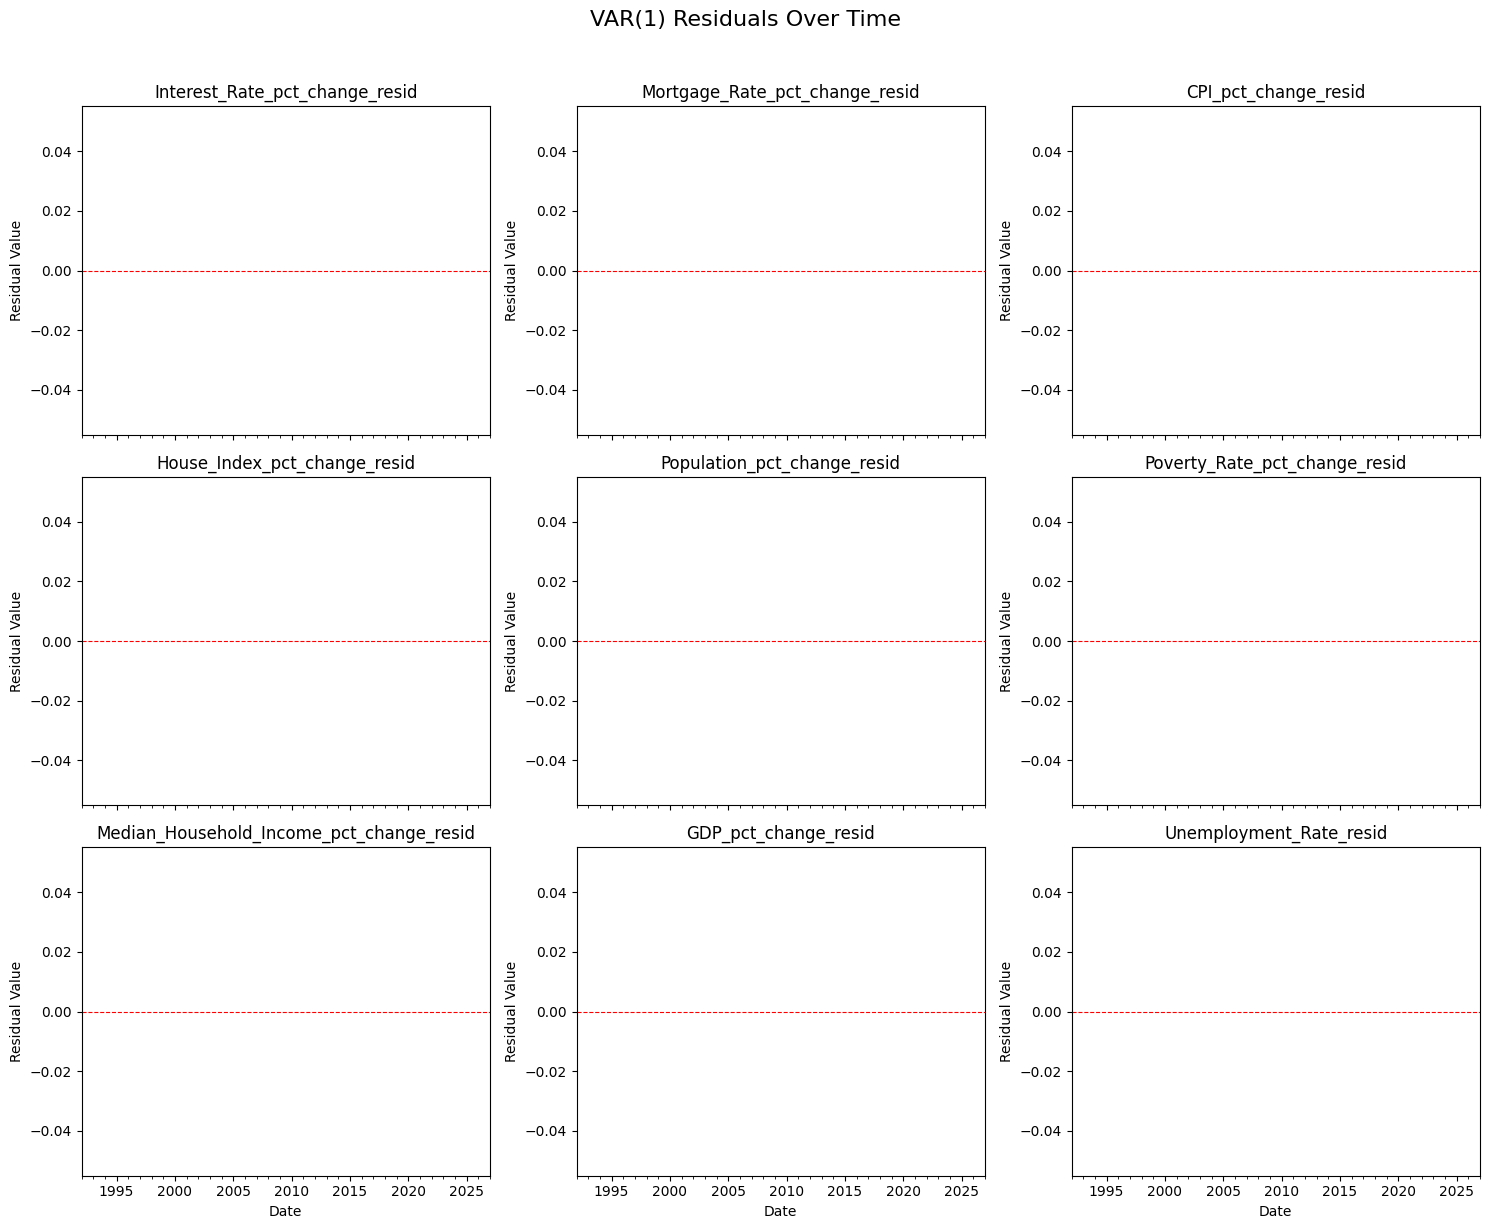


--- Forecasting ---
Generating forecast for the next 8 steps...

Forecast for the next 8 steps:
            Interest_Rate_pct_change_forecast  \
2027-03-31                           0.085744   
2027-06-30                           0.099304   
2027-09-30                           0.128377   
2027-12-31                           0.177504   
2028-03-31                           0.066945   
2028-06-30                           0.070301   
2028-09-30                           0.135405   
2028-12-31                           0.136769   

            Mortgage_Rate_pct_change_forecast  CPI_pct_change_forecast  \
2027-03-31                          -0.029431                 0.008306   
2027-06-30                          -0.012633                 0.004288   
2027-09-30                          -0.015789                 0.003210   
2027-12-31                          -0.019522                 0.003127   
2028-03-31                          -0.014107                 0.007322   
2028-06-30       

In [47]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR # Import VAR model
import matplotlib.pyplot as plt # Import for plotting
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. Load Percentage Change Data ---
try:
    df_pct = pd.read_csv("DC_Master_ARIMA_Filled_pct_change.csv", parse_dates=['Date'], index_col='Date')
    print(f"Data loaded successfully. Shape: {df_pct.shape}")

    df = df_pct[df_pct.index <= '2024-10-01']

        # --- 2. Create Dummy Variables (Period-Specific) and Identify Exogenous Series ---
    print("\n--- Creating Exogenous Variables ---")

    # Crisis dummy: 1 from 2007 Q4 through 2009 Q4
    crisis_start_date = '2007-10-01'
    crisis_stop_date = '2009-10-01' # End of Q4 2009
    df['dummy_crisis_2008_period'] = 0 # Initialize column
    # Select rows between start and stop dates (inclusive)
    df.loc[(df.index >= crisis_start_date) & (df.index <= crisis_stop_date), 'dummy_crisis_2008_period'] = 1
    print(f"Created 'dummy_crisis_2008_period' (active {crisis_start_date} to {crisis_stop_date})")

    # COVID dummy: 1 from 2020 Q1 through 2021 Q4
    covid_start_date = '2020-01-01'
    covid_stop_date = '2021-10-01' # End of Q4 2021
    df['dummy_covid_2020_period'] = 0 # Initialize column
    # Select rows between start and stop dates (inclusive)
    df.loc[(df.index >= covid_start_date) & (df.index <= covid_stop_date), 'dummy_covid_2020_period'] = 1
    print(f"Created 'dummy_covid_2020_period' (active {covid_start_date} to {covid_stop_date})")


    # --- 2. Select Variables for VAR ---
    var_cols = ['Interest_Rate_pct_change', 'Mortgage_Rate_pct_change', 'CPI_pct_change',
                'House_Index_pct_change', 'Population_pct_change', 'Poverty_Rate_pct_change',
                'Median_Household_Income_pct_change', 'GDP_pct_change', 'Unemployment_Rate'] # Your variable list
    print(f"\nUsing columns for VAR: {var_cols}")
    df_var_data = df_pct[var_cols].copy()

    # --- 3. Handle Missing Values ---
    initial_rows = df_var_data.shape[0]
    df_var_input = df_var_data.dropna()
    rows_dropped = initial_rows - df_var_input.shape[0]
    print(f"\nHandling NaNs. Rows dropped: {rows_dropped}")
    print(f"Final data shape for VAR input: {df_var_input.shape}")

    if df_var_input.shape[0] < df_var_input.shape[1]:
        raise ValueError("Error: Not enough data points remaining for VAR estimation.")

    # --- 4. Choose Lag Order p ---
    # Based on the select_order output (BIC/HQIC=1, AIC/FPE=7)
    # Starting with the BIC/HQIC suggestion
    # p = 1
    p = 7 # <-- Uncomment this line and comment above line to use AIC/FPE suggestion
    print(f"\nSelected VAR lag order p = {p}")

    # --- 5. Fit the VAR Model ---
    print(f"\n--- Fitting VAR({p}) model with trend='ct' ---")
    # Instantiate the model (trend is specified in fit, not here)
    model = VAR(endog=df_var_input)

    # Fit the model using the chosen lag order 'p' and specifying the trend
    var_results = model.fit(maxlags=p, trend='ct')

    # --- 6. Display VAR Results Summary ---
    print("\n--- VAR Estimation Results ---")
    print(var_results.summary())

    # --- 7. Residual Diagnostics (CRUCIAL - Corrected Methods) ---
    print("\n--- Residual Diagnostics ---")
    print("\nResidual Autocorrelation Test (Whiteness Test):")
    # Test if residuals resemble white noise using Portmanteau test (Ljung-Box)
    diag_lags = 8 # Test up to 8 lags (as discussed)
    print(f"Portmanteau test up to {diag_lags} lags:")
    try:
        # Try test_whiteness as the method for Portmanteau test
        # Note: test_whiteness itself might call acorr_ljungbox
        # We pass adjusted=True which is often recommended
        portmanteau_results = var_results.test_whiteness(nlags=diag_lags, adjusted=True)
        print(portmanteau_results.summary())
        # Check the p-value. High p-value (> 0.05) is desired (no autocorrelation).
    except AttributeError:
        print("'.test_whiteness()' not found. Trying 'acorr_ljungbox' on residuals directly...")
        # Fallback: Calculate manually using ljungbox on each residual series
        from statsmodels.stats.diagnostic import acorr_ljungbox
        all_resid_ok = True
        for i, col in enumerate(df_var_input.columns):
             lb_test = acorr_ljungbox(var_results.resid[:,i], lags=[diag_lags], return_df=True)
             p_val = lb_test['lb_pvalue'].iloc[0]
             print(f"Ljung-Box test for {col}: p-value = {p_val:.4f}")
             if p_val <= 0.05:
                  all_resid_ok = False
        if all_resid_ok:
             print("Conclusion: No significant autocorrelation detected in individual series (at 5% level).")
        else:
             print("Warning: Significant autocorrelation detected in at least one series.")
    except Exception as diag_e:
         print(f"Could not perform residual autocorrelation test: {diag_e}")


    print("\nResidual Normality Test:")
    # This part seemed to work before, keeping it
    try:
        normality_results = var_results.test_normality()
        print(normality_results.summary())
        # Check Jarque-Bera test p-value. High p-value (> 0.05) is desired (residuals are normal).
    except Exception as diag_e:
         print(f"Could not perform residual normality test: {diag_e}")

    # --- 8. Plot Residuals (Corrected Method - Manual Plot) ---
    print("\n--- Plotting VAR Residuals ---")
    try:
        residuals = var_results.resid
        # Create DataFrame for easier plotting
        residuals_df = pd.DataFrame(residuals,
                                    index=df_var_input.index[var_results.k_ar:], # Adjust index for lags used
                                    columns=df_var_input.columns + '_resid')

        num_variables = residuals_df.shape[1]
        num_cols = 3 # Adjust layout if needed
        num_rows = int(np.ceil(num_variables / num_cols))

        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4), sharex=True)
        axes = axes.flatten()

        for i, col in enumerate(residuals_df.columns):
            if i < len(axes):
                residuals_df[col].plot(ax=axes[i], title=col)
                axes[i].set_ylabel('Residual Value')
                axes[i].axhline(0, color='red', linestyle='--', linewidth=0.8)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle('VAR(1) Residuals Over Time', fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
    except Exception as plot_e:
        print(f"Could not plot residuals: {plot_e}")
    # --- 9. Forecasting ---
    print("\n--- Forecasting ---")
    try:
        num_forecast_steps = 8
        print(f"Generating forecast for the next {num_forecast_steps} steps...")
        # Get the last 'p' observations needed for forecasting
        last_observations = df_var_input.values[-p:]
        # Forecast
        forecast_values = var_results.forecast(y=last_observations, steps=num_forecast_steps)

        # Create forecast index
        freq = df_var_input.index.freq
        if freq is None:
            print("Warning: Data frequency not detected, assuming quarterly for forecast index.")
            freq = pd.tseries.offsets.QuarterEnd()
        forecast_index = pd.date_range(start=df_var_input.index[-1] + freq,
                                       periods=num_forecast_steps,
                                       freq=freq)

        # Create forecast DataFrame
        forecast_df = pd.DataFrame(forecast_values, index=forecast_index, columns=df_var_input.columns + '_forecast')
        print(f"\nForecast for the next {num_forecast_steps} steps:")
        print(forecast_df)

        # Confidence intervals (Optional - can use forecast_interval)
        # forecast_intervals = var_results.forecast_interval(y=last_observations, steps=num_forecast_steps, alpha=0.05)
        # lower_ci = forecast_intervals[1]
        # upper_ci = forecast_intervals[2]
        # lower_ci_df = pd.DataFrame(lower_ci, index=forecast_index, columns=df_var_input.columns + '_lower_ci')
        # upper_ci_df = pd.DataFrame(upper_ci, index=forecast_index, columns=df_var_input.columns + '_upper_ci')
        # print("\nForecast Confidence Intervals (95%):")
        # print(lower_ci_df)
        # print(upper_ci_df)

    except Exception as fc_e:
        print(f"An error occurred during forecasting: {fc_e}")


except FileNotFoundError:
    print(f"Error: The file 'DC_Master_ARIMA_Filled_pct_change.csv' was not found.")
except ValueError as ve:
    print(ve)
except KeyError as ke:
    print(f"Error: Column not found. Please check the column names in 'var_cols'. Details: {ke}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [48]:
df = pd.read_csv("DC_Master_ARIMA_Filled_pct_change.csv", parse_dates=['Date'], index_col='Date')

    # 2. Create Dummy Variables (Period-Specific) 

# Crisis dummy: 1 from 2007 Q4 through 2009 Q4
crisis_start_date = '2007-10-01'
crisis_stop_date = '2009-10-01' # End of Q4 2009
df['dummy_crisis_2008_period'] = 0 # Initialize column
# Select rows between start and stop dates (inclusive)
df.loc[(df.index >= crisis_start_date) & (df.index <= crisis_stop_date), 'dummy_crisis_2008_period'] = 1
print(f"Created 'dummy_crisis_2008_period' (active {crisis_start_date} to {crisis_stop_date})")

# COVID dummy: 1 from 2020 Q1 through 2021 Q4
covid_start_date = '2020-01-01'
covid_stop_date = '2021-10-01' # End of Q4 2021
df['dummy_covid_2020_period'] = 0 # Initialize column
# Select rows between start and stop dates (inclusive)
df.loc[(df.index >= covid_start_date) & (df.index <= covid_stop_date), 'dummy_covid_2020_period'] = 1
print(f"Created 'dummy_covid_2020_period' (active {covid_start_date} to {covid_stop_date})")

# Save the DataFrame to a new CSV file
df.to_csv("DC_Master_ARIMA_Filled_pct_change_dummies.csv", index=True)

Created 'dummy_crisis_2008_period' (active 2007-10-01 to 2009-10-01)
Created 'dummy_covid_2020_period' (active 2020-01-01 to 2021-10-01)
